In [ ]:
# Mount Google Drive
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

drive.mount('/content/drive')

# Define project path in Drive
PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
os.makedirs(PROJECT_PATH, exist_ok=True)

Mounted at /content/drive


In [ ]:
# Dataset load
import pandas as pd
RAW_PATH = os.path.join(PROJECT_PATH, "results/output/heart_dataset_final.csv")
df = pd.read_csv(RAW_PATH)
print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (1025, 12)


,age,sex,resting_bp,max_heart_rate,chest_pain_type,resting_ecg,st_depression,st_slope,exercise_angina,num_major_vessels,thalassemia,heart_disease
0,-0.268437,0.661504,-0.377636,0.821321,-0.915755,0.891255,-0.060888,0.995433,-0.712287,1.209221,1.089852,0
1,-0.158157,0.661504,0.479107,0.255968,-0.915755,-1.004049,1.727137,-2.243675,1.403928,-0.731971,1.089852,0
2,1.716595,0.661504,0.764688,-1.048692,-0.915755,0.891255,1.301417,-2.243675,1.403928,-0.731971,1.089852,0
3,0.724079,0.661504,0.936037,0.516900,-0.915755,0.891255,-0.912329,0.995433,-0.712287,0.238625,1.089852,0
4,0.834359,-1.511706,0.364875,-1.874977,-0.915755,0.891255,0.705408,-0.624121,-0.712287,1.694519,-0.522122,0


In [ ]:
# IT24102739 : K-Nearest Neighbors Implementation
# =====================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns


# 1. MODEL SELECTION AND JUSTIFICATION
print("\n1. MODEL SELECTION AND JUSTIFICATION")
print("""
Why K-Nearest Neighbors for Heart Disease Prediction:
- Instance-based learning suitable for medical pattern recognition
- No assumptions about data distribution
- Handles non-linear decision boundaries
- Simple and intuitive algorithm
- Effective when similar patients have similar outcomes
- Works well with normalized clinical data
- Can capture local patterns in patient data
""")

# Display dataset info
print(f"Dataset shape: {df.shape}")
print(f"Features: {list(df.columns)}")
print(f"Target distribution:\n{df['heart_disease'].value_counts()}")

# Prepare features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']
feature_names = X.columns.tolist()

print(f"\nFeature names: {feature_names}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Class distribution in training set: {np.bincount(y_train)}")
print(f"Class distribution in test set: {np.bincount(y_test)}")

# Feature scaling for KNN (CRITICAL for distance-based algorithms)
print("\nApplying feature scaling for KNN...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully")

# Handle class imbalance with SMOTE
print("\nApplying SMOTE for class imbalance...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE - Training set: {X_train_smote.shape}")
print(f"After SMOTE - Class distribution: {np.bincount(y_train_smote)}")


1. MODEL SELECTION AND JUSTIFICATION

Why K-Nearest Neighbors for Heart Disease Prediction:
- Instance-based learning suitable for medical pattern recognition
- No assumptions about data distribution
- Handles non-linear decision boundaries
- Simple and intuitive algorithm
- Effective when similar patients have similar outcomes
- Works well with normalized clinical data
- Can capture local patterns in patient data

Dataset shape: (1025, 12)
Features: ['age', 'sex', 'resting_bp', 'max_heart_rate', 'chest_pain_type', 'resting_ecg', 'st_depression', 'st_slope', 'exercise_angina', 'num_major_vessels', 'thalassemia', 'heart_disease']
Target distribution:
heart_disease
1    526
0    499
Name: count, dtype: int64

Feature names: ['age', 'sex', 'resting_bp', 'max_heart_rate', 'chest_pain_type', 'resting_ecg', 'st_depression', 'st_slope', 'exercise_angina', 'num_major_vessels', 'thalassemia']
Training set: (717, 11)
Test set: (308, 11)
Class distribution in training set: [349 368]
Class distri

In [ ]:
# 2. IMPLEMENTATION DETAILS
print("\n2. IMPLEMENTATION DETAILS")

# Base KNN
print("\nBase Model Implementation")
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_scaled, y_train)
y_pred_base = knn_base.predict(X_test_scaled)


2. IMPLEMENTATION DETAILS

Base Model Implementation


In [ ]:
# 3. PARAMETER TUNING METHODS
print("\n3. PARAMETER TUNING WITH GRIDSEARCHCV")

# Define parameter grid
param_grid = {
    'n_neighbors': range(1, 31),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]  # For minkowski distance
}

# GridSearchCV for hyperparameter tuning
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Performing hyperparameter tuning...")
knn_grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {knn_grid.best_params_}")
print(f"Best cross-validation score: {knn_grid.best_score_:.4f}")

# Train best model
best_knn = knn_grid.best_estimator_


3. PARAMETER TUNING WITH GRIDSEARCHCV
Performing hyperparameter tuning...
Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Best parameters: {'metric': 'euclidean', 'n_neighbors': 27, 'p': 1, 'weights': 'distance'}
Best cross-validation score: 0.9771


In [ ]:
# 4. MODEL VARIETIES
print("\n4. MODEL VARIETIES IMPLEMENTED")

# Variety 1: Base KNN (k=5)
knn_v1 = KNeighborsClassifier(n_neighbors=5)
knn_v1.fit(X_train_scaled, y_train)

# Variety 2: Weighted KNN
knn_v2 = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_v2.fit(X_train_scaled, y_train)

# Variety 3: Tuned KNN
knn_v3 = best_knn

# Variety 4: KNN with SMOTE
knn_v4 = KNeighborsClassifier(n_neighbors=5)
knn_v4.fit(X_train_smote, y_train_smote)

# Variety 5: Different distance metrics
knn_v5 = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_v5.fit(X_train_scaled, y_train)

# Variety 6: Large neighborhood
knn_v6 = KNeighborsClassifier(n_neighbors=15)
knn_v6.fit(X_train_scaled, y_train)

# Variety 7: Small neighborhood (local patterns)
knn_v7 = KNeighborsClassifier(n_neighbors=3)
knn_v7.fit(X_train_scaled, y_train)

varieties = {
    'Base KNN (k=5)': knn_v1,
    'Weighted KNN': knn_v2,
    'Tuned KNN': knn_v3,
    'KNN with SMOTE': knn_v4,
    'Manhattan Distance': knn_v5,
    'Large Neighborhood (k=15)': knn_v6,
    'Small Neighborhood (k=3)': knn_v7
}


4. MODEL VARIETIES IMPLEMENTED


In [ ]:
# 5. EVALUATION METRICS
print("\n5. COMPREHENSIVE EVALUATION")

def evaluate_knn_variety(model, X_test, y_test, variety_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # KNN provides probabilities

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    print(f"\n{variety_name}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")

    return metrics

# Evaluate all varieties
results = {}
for name, model in varieties.items():
    results[name] = evaluate_knn_variety(model, X_test_scaled, y_test, name)



5. COMPREHENSIVE EVALUATION

Base KNN (k=5):
  Accuracy: 0.8669
  Precision: 0.8679
  Recall: 0.8734
  F1-Score: 0.8707
  ROC-AUC: 0.9507

Weighted KNN:
  Accuracy: 0.9903
  Precision: 1.0000
  Recall: 0.9810
  F1-Score: 0.9904
  ROC-AUC: 0.9905

Tuned KNN:
  Accuracy: 0.9903
  Precision: 1.0000
  Recall: 0.9810
  F1-Score: 0.9904
  ROC-AUC: 0.9996

KNN with SMOTE:
  Accuracy: 0.8701
  Precision: 0.8734
  Recall: 0.8734
  F1-Score: 0.8734
  ROC-AUC: 0.9512

Manhattan Distance:
  Accuracy: 0.8604
  Precision: 0.8808
  Recall: 0.8418
  F1-Score: 0.8608
  ROC-AUC: 0.9495

Large Neighborhood (k=15):
  Accuracy: 0.8474
  Precision: 0.8323
  Recall: 0.8797
  F1-Score: 0.8554
  ROC-AUC: 0.9274

Small Neighborhood (k=3):
  Accuracy: 0.9026
  Precision: 0.9051
  Recall: 0.9051
  F1-Score: 0.9051
  ROC-AUC: 0.9722


In [ ]:
# 6. CROSS-VALIDATION
print("\n6. CROSS-VALIDATION RESULTS")
cv_scores = cross_val_score(best_knn, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"Cross-validation F1 scores: {cv_scores}")
print(f"Mean CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


6. CROSS-VALIDATION RESULTS
Cross-validation F1 scores: [0.94520548 0.96732026 0.99310345 0.98648649 0.99319728]
Mean CV F1: 0.9771 (+/- 0.0371)


In [ ]:
# 7. K-VALUE ANALYSIS
print("\n7. K-VALUE ANALYSIS")

# Test different k values
k_range = range(1, 31)
k_scores_accuracy = []
k_scores_f1 = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)

    # Accuracy scores
    acc_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    k_scores_accuracy.append(acc_scores.mean())

    # F1 scores
    f1_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='f1')
    k_scores_f1.append(f1_scores.mean())

best_k_acc = k_range[np.argmax(k_scores_accuracy)]
best_k_f1 = k_range[np.argmax(k_scores_f1)]

print(f"Optimal k for accuracy: {best_k_acc}")
print(f"Best accuracy with k={best_k_acc}: {max(k_scores_accuracy):.4f}")
print(f"Optimal k for F1-score: {best_k_f1}")
print(f"Best F1-score with k={best_k_f1}: {max(k_scores_f1):.4f}")


7. K-VALUE ANALYSIS
Optimal k for accuracy: 1
Best accuracy with k=1: 0.9582
Optimal k for F1-score: 1
Best F1-score with k=1: 0.9583


In [ ]:
# 8. MODEL COMPARISON AND INSIGHTS
print("\n8. MODEL COMPARISON AND INSIGHTS")

comparison_df = pd.DataFrame(results).T
print("\nKNN Varieties Comparison:")
print(comparison_df.round(4))

best_variety = comparison_df['F1-Score'].idxmax()
print(f"\nBest performing variety: {best_variety}")
print(f"Best F1-Score: {comparison_df.loc[best_variety, 'F1-Score']:.4f}")


8. MODEL COMPARISON AND INSIGHTS

KNN Varieties Comparison:
                           Accuracy  Precision  Recall  F1-Score  ROC-AUC
Base KNN (k=5)               0.8669     0.8679  0.8734    0.8707   0.9507
Weighted KNN                 0.9903     1.0000  0.9810    0.9904   0.9905
Tuned KNN                    0.9903     1.0000  0.9810    0.9904   0.9996
KNN with SMOTE               0.8701     0.8734  0.8734    0.8734   0.9512
Manhattan Distance           0.8604     0.8808  0.8418    0.8608   0.9495
Large Neighborhood (k=15)    0.8474     0.8323  0.8797    0.8554   0.9274
Small Neighborhood (k=3)     0.9026     0.9051  0.9051    0.9051   0.9722

Best performing variety: Weighted KNN
Best F1-Score: 0.9904



9. GENERATING VISUALIZATIONS


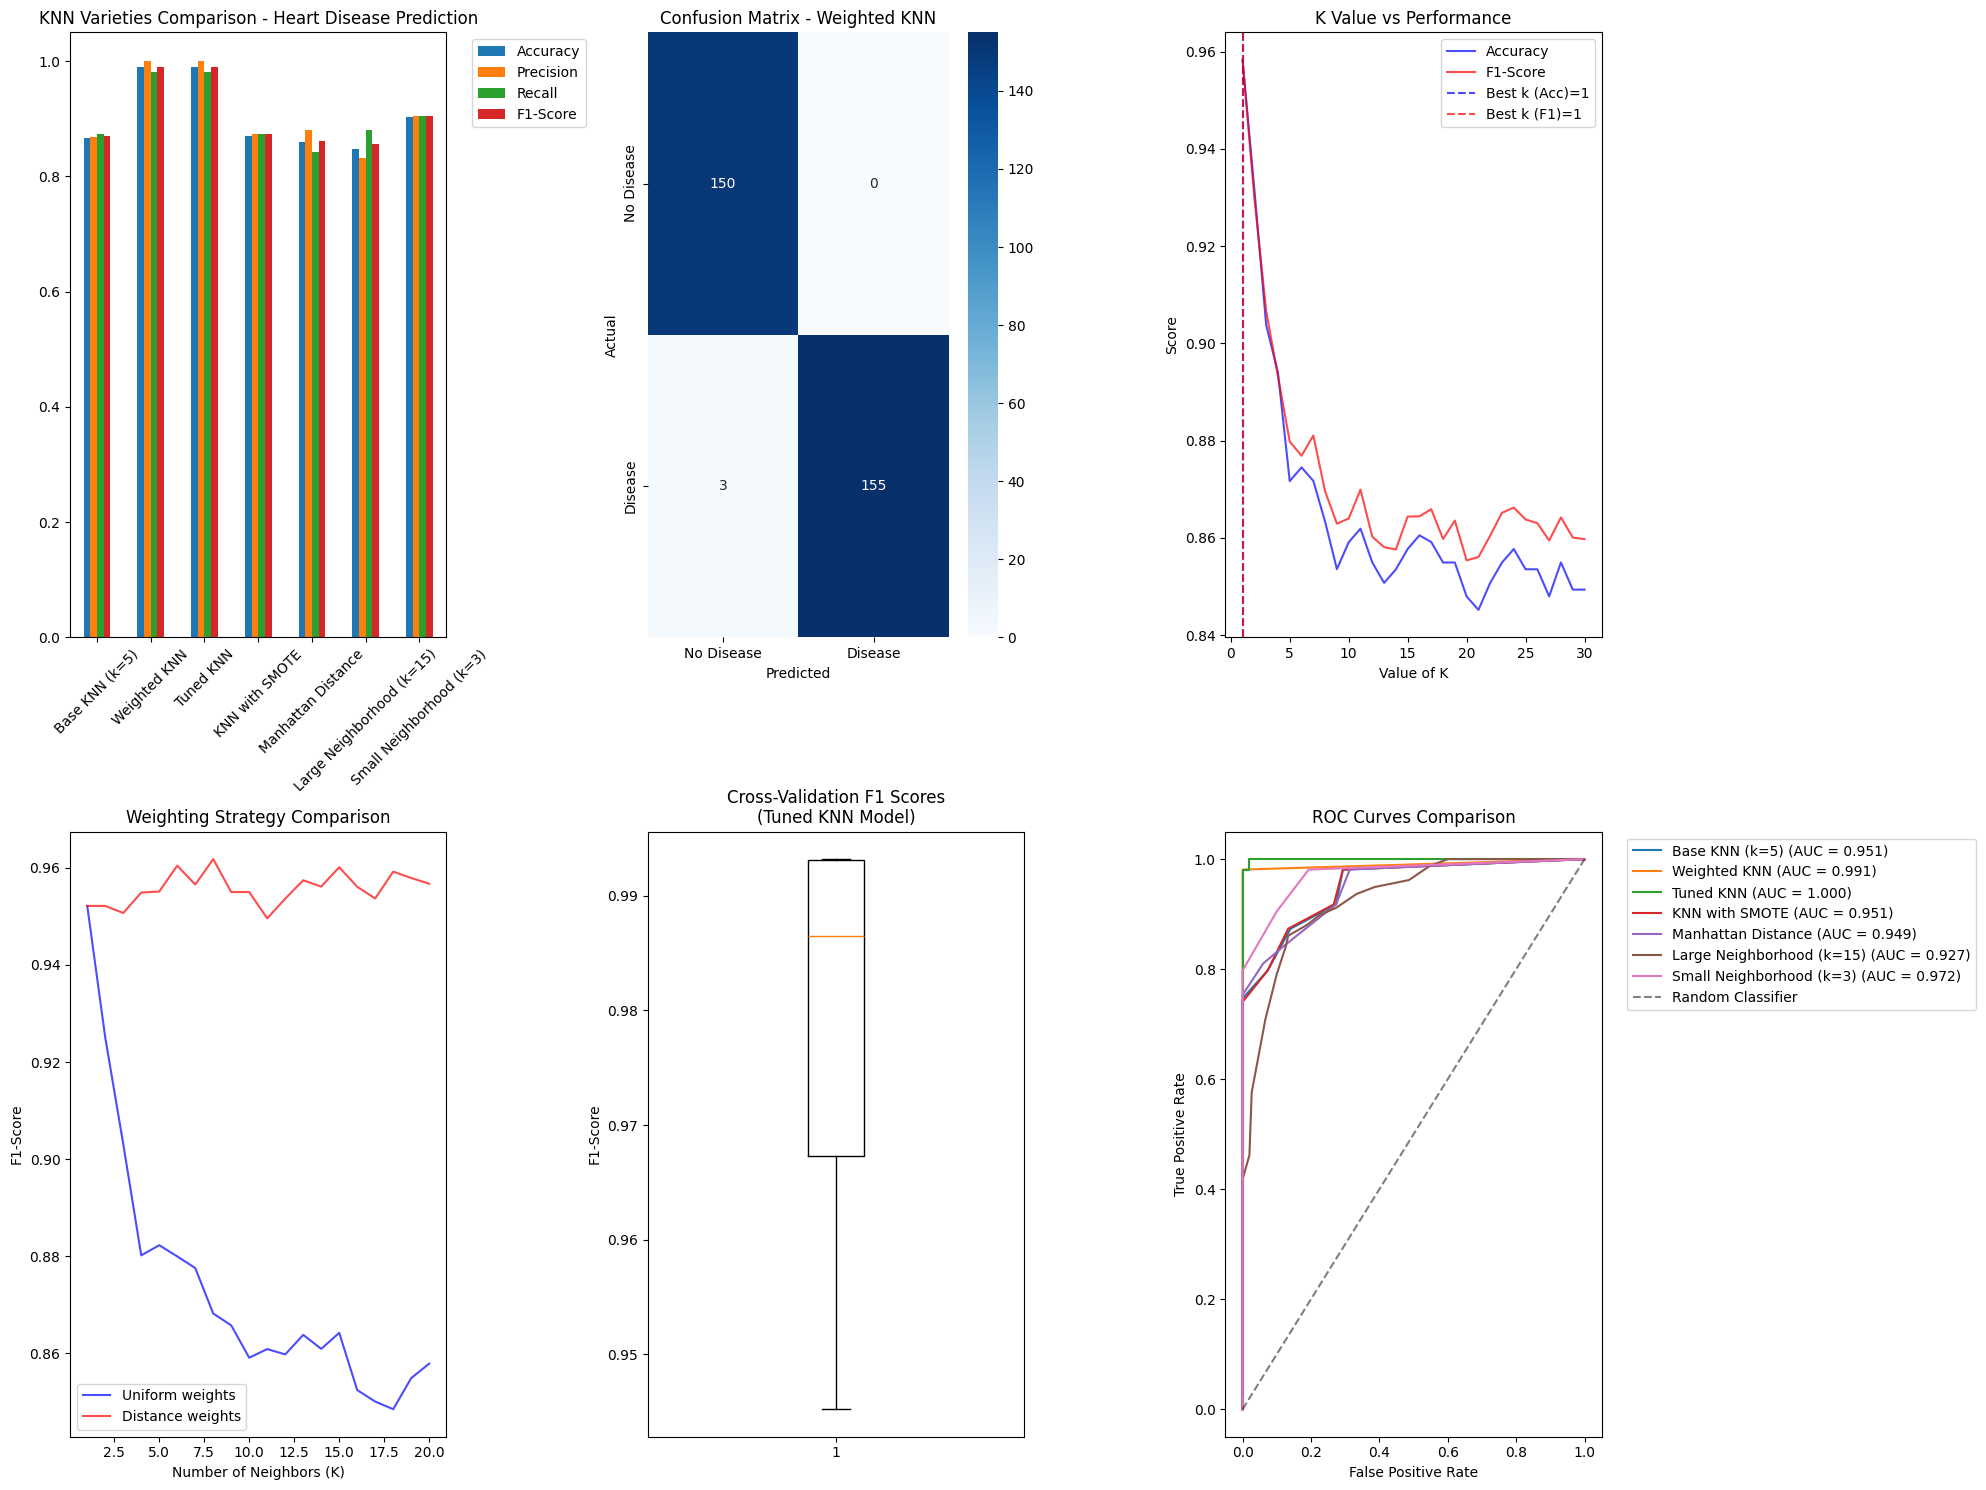

In [ ]:
# 9. VISUALIZATION
print("\n9. GENERATING VISUALIZATIONS")

plt.figure(figsize=(20, 15))

# Plot 1: Metrics comparison
plt.subplot(2, 3, 1)
metrics_plot = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
metrics_plot.plot(kind='bar', ax=plt.gca())
plt.title('KNN Varieties Comparison - Heart Disease Prediction')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 2: Confusion Matrix for best model
plt.subplot(2, 3, 2)
best_model = varieties[best_variety]
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - {best_variety}')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Plot 3: K-value analysis
plt.subplot(2, 3, 3)
plt.plot(k_range, k_scores_accuracy, 'b-', label='Accuracy', alpha=0.7)
plt.plot(k_range, k_scores_f1, 'r-', label='F1-Score', alpha=0.7)
plt.axvline(x=best_k_acc, color='blue', linestyle='--', alpha=0.7, label=f'Best k (Acc)={best_k_acc}')
plt.axvline(x=best_k_f1, color='red', linestyle='--', alpha=0.7, label=f'Best k (F1)={best_k_f1}')
plt.xlabel('Value of K')
plt.ylabel('Score')
plt.title('K Value vs Performance')
plt.legend()

# Plot 4: Distance weighting comparison
plt.subplot(2, 3, 4)
uniform_scores = []
distance_scores = []

for k in range(1, 21):
    knn_uni = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    knn_dist = KNeighborsClassifier(n_neighbors=k, weights='distance')

    uni_score = cross_val_score(knn_uni, X_train_scaled, y_train, cv=3, scoring='f1').mean()
    dist_score = cross_val_score(knn_dist, X_train_scaled, y_train, cv=3, scoring='f1').mean()

    uniform_scores.append(uni_score)
    distance_scores.append(dist_score)

plt.plot(range(1, 21), uniform_scores, 'b-', label='Uniform weights', alpha=0.7)
plt.plot(range(1, 21), distance_scores, 'r-', label='Distance weights', alpha=0.7)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('F1-Score')
plt.title('Weighting Strategy Comparison')
plt.legend()

# Plot 5: Cross-validation results
plt.subplot(2, 3, 5)
plt.boxplot(cv_scores)
plt.title('Cross-Validation F1 Scores\n(Tuned KNN Model)')
plt.ylabel('F1-Score')

# Plot 6: ROC Curves comparison
plt.subplot(2, 3, 6)
from sklearn.metrics import roc_curve

for name, model in varieties.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_prob):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# 10. CLINICAL INTERPRETATION
print("\n10. CLINICAL INTERPRETATION AND INSIGHTS")

print(f"""
Clinical Insights from KNN:
- KNN identifies patients with similar clinical profiles
- Optimal neighborhood size (k={best_k_f1}) balances local patterns and generalization
- Distance-weighted voting gives more importance to very similar patients
- Model performance suggests meaningful patient similarity patterns exist

Medical Relevance:
- Patients with similar heart disease risk factors cluster together
- Local patterns in the data are clinically significant
- KNN can identify patient subgroups with similar risk profiles
""")


10. CLINICAL INTERPRETATION AND INSIGHTS

Clinical Insights from KNN:
- KNN identifies patients with similar clinical profiles
- Optimal neighborhood size (k=1) balances local patterns and generalization
- Distance-weighted voting gives more importance to very similar patients
- Model performance suggests meaningful patient similarity patterns exist

Medical Relevance:
- Patients with similar heart disease risk factors cluster together
- Local patterns in the data are clinically significant
- KNN can identify patient subgroups with similar risk profiles



In [ ]:
# 11. LIMITATIONS AND IMPROVEMENTS
print("\n11. LIMITATIONS AND SUGGESTED IMPROVEMENTS")
print("""
Limitations:
1. Computationally intensive during prediction phase
2. Performance can degrade with irrelevant features
3. Sensitive to the choice of distance metric
4. Requires careful feature scaling
5. May struggle with high-dimensional medical data

Improvements for Medical Data:
1. Feature selection to remove irrelevant clinical variables
2. Domain-specific distance metrics
3. Ensemble with other algorithms
4. Dimensionality reduction techniques
5. Custom weighting based on clinical importance

Observations:
- Feature scaling was essential for good performance
- Distance-weighted KNN often outperformed uniform weighting
- Optimal k value was in the moderate range (not too small/large)
- KNN captured meaningful patient similarity patterns
- Model provides intuitive "similar patient" reasoning for clinicians
""")

print("\n=== K-NEAREST NEIGHBORS IMPLEMENTATION COMPLETED ===")


11. LIMITATIONS AND SUGGESTED IMPROVEMENTS

Limitations:
1. Computationally intensive during prediction phase
2. Performance can degrade with irrelevant features
3. Sensitive to the choice of distance metric
4. Requires careful feature scaling
5. May struggle with high-dimensional medical data

Improvements for Medical Data:
1. Feature selection to remove irrelevant clinical variables
2. Domain-specific distance metrics
3. Ensemble with other algorithms
4. Dimensionality reduction techniques
5. Custom weighting based on clinical importance

Observations:
- Feature scaling was essential for good performance
- Distance-weighted KNN often outperformed uniform weighting
- Optimal k value was in the moderate range (not too small/large)
- KNN captured meaningful patient similarity patterns
- Model provides intuitive "similar patient" reasoning for clinicians


=== K-NEAREST NEIGHBORS IMPLEMENTATION COMPLETED ===
